# Linear Combinations and Span

This notebook explains:
- What linear combinations are
- What span means geometrically
- Why linear independence matters
- How this connects to Machine Learning


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### ✅ Example 1: Linear combinations → span

## Linear Combination — Intuition

A **linear combination** looks like this:

a · v₁ + b · v₂

Meaning:
- Walk `a` steps in direction v₁
- Walk `b` steps in direction v₂
- Where do you land?

If we try **all possible a and b**,  
all landing points together form the **span**.


In [4]:
def generate_linear_combinations(v1, v2, scale_range):
    """
    Generates all linear combinations:
    a*v1 + b*v2 for a, b in given range
    
    Parameters:
    v1, v2 : numpy arrays (vectors)
    scale_range : range of integers (e.g., range(-5, 5))
    
    Returns:
    numpy array of points
    """
    points = []
    for a in scale_range:
        for b in scale_range:
            point = a * v1 + b * v2
            points.append(point)
    return np.array(points)


## Example 1: Independent Vectors → Full 2D Span

If two vectors point in **different directions**,  
their span covers the entire plane.


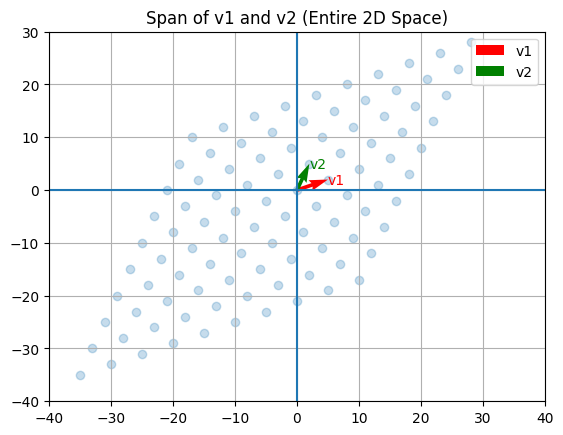

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# define 2 vectors with directions of x and y axes
v1 = np.array([5,2]) # x axis   
v2 = np.array([2,5]) # y axis

# create an empty list  called points
points = [a*v1 + b*v2 for b in range(-5,5) for a in range(-5,5)]

# create a list of points in a grid 
# using two nested for loops

# for a in range(-5, 5):           # a controls how far along v1 (x axis)
#         for b in range(-5,5):    # b controls how far along v2 (y axis)
#                 point  = (a * v1) + (b  * v2)   # If I walk a steps in direction v1 and b steps in direction v2, where do I land?
#                 points.append(point)          # add that point to the list

points = np.array(points)   

origin = np.zeros([0,0]) #create origin ot use 0, 0 

#  plotting scatter to find the points where they are pointing
plt.scatter(points[:,0], points[:,1], alpha =0.25)  
# “Give me every x-value from all points”
# where [:,0] every row and 0th Column, 
# “Give me every y-value from all points”
# where [:,1] every row and 1st Column, 

plt.quiver(*origin, v1[0],v1[1],color = 'red' ,  #create quiver plot with v1
        scale_units = 'xy',scale =1,             #and scale 1 with units & angles xy
        angles = 'xy', label = 'v1')
plt.quiver(*origin,v2[0],v2[1], color = 'green',   #create quiver plot with v2
        scale_units = 'xy', scale = 1,             #and scale 1 with units & angles xy
        angles= 'xy', label = 'v2')

plt.text(v1[0],v1[1]/2,f'v1',color = 'red')
plt.text(v2[0],v2[1]/1.2,f'v2',color = 'green')

plt.xlim(-40,40)
plt.ylim(-40,30)

plt.axhline(0); # DRAW horizontal axis
plt.axvline(0) # DRAW vertical axis
plt.grid()      # draw a grid line
plt.legend()
plt.title("Span of v1 and v2 (Entire 2D Space)")
plt.show()


# 🧠 What you just saw
# Every dot = one linear combination
# All dots together = span
# Red & Green arrows = basis vectors

## Example 2: Dependent Vectors → No Full Span

Even with two vectors,  
if one depends on the other,  
their span collapses to a **line**.


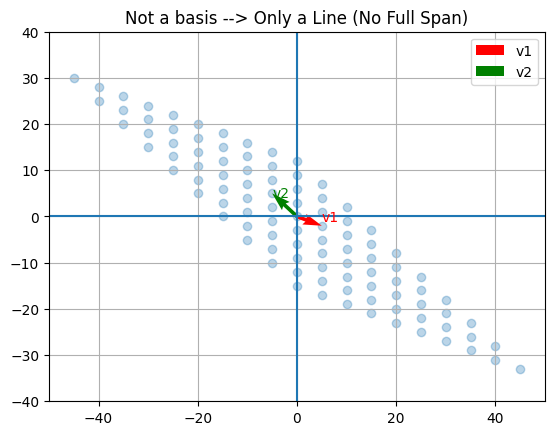

In [23]:
# define 2 vectors with directions of x and y axes
v1 = np.array([5,-2]) # x axis
v2 = np.array([-5,5]) # y axis


# create an empty list  called points
points = [(a*v1+b*v2) for b in range(-5,5) for a in range(-5,5)]

# create a list of points in a grid 
# using two nested for loops
# for a in range(-5, 5):           # a controls how far along v1 (x axis)
#         for b in range(-5,5):    # b controls how far along v2 (y axis)
#                 point  = (a * v1) + (b  * v2)   # If I walk a steps in direction v1 and b steps in direction v2, where do I land?
#                 points.append(point)          # add that point to the list
points = np.array(points)   

origin = np.zeros([0,0]) #create origin ot use 0, 0 

#  plotting scatter to find the points where they are pointing
plt.scatter(points[:,0], points[:,1], alpha =0.3)  
# “Give me every x-value from all points”
# where [:,0] every row and 0th Column, 
# “Give me every y-value from all points”
# where [:,1] every row and 1st Column, 

plt.quiver(*origin, v1[0],v1[1],color = 'red' ,  #create quiver plot with v1
        scale_units = 'xy',scale =1,             #and scale 1 with units & angles xy
        angles = 'xy', label = 'v1')
plt.quiver(*origin,v2[0],v2[1], color = 'green',   #create quiver plot with v2
        scale_units = 'xy', scale = 1,             #and scale 1 with units & angles xy
        angles= 'xy', label = 'v2')

plt.text(v1[0],v1[1]/2,f'v1',color = 'red')
plt.text(v2[0],v2[1]/1.2,f'v2',color = 'green')

plt.xlim(-50,50)
plt.ylim(-40,40)

plt.axhline(0); # DRAW horizontal axis
plt.axvline(0) # DRAW vertical axis
plt.grid()      # draw a grid line
plt.legend()
plt.title('Not a basis --> Only a Line (No Full Span)')
plt.show()


# 🧠 What you just saw
# 🔑 Insight Even with two vectors, 
# if they’re dependent → no plane, only a line. 
# Quantity doesn’t matter. Independence does.

### Key Insight

- Number of vectors ≠ dimension of span
- Independence matters more than quantity

Two dependent vectors behave like **one**


## Why This Matters in Machine Learning

- Columns of dataset = feature vectors
- Dependent features → redundant information
- Causes:
  - Multicollinearity
  - Unstable models
  - Poor generalization

In ML terms:
> Rank of matrix < number of features → problem
